<a href="https://colab.research.google.com/github/ANKIAbhishek2006/CSA0404-ABHISHEK/blob/main/ML_Lab_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment-1

In [1]:
data = [
    ['Sunny','Warm','Normal','Strong','Warm','Same','Yes'],
    ['Sunny','Warm','High','Strong','Warm','Same','Yes'],
    ['Rainy','Cold','High','Strong','Warm','Change','No'],
    ['Sunny','Warm','High','Strong','Cool','Change','Yes']
]
h = ['0'] * (len(data[0]) - 1)
print("Initial Hypothesis:", h)
for example in data:
    if example[-1] == "Yes":
        for i in range(len(h)):
            if h[i] == '0':
                h[i] = example[i]
            elif h[i] != example[i]:
                h[i] = '?'
print("Final Hypothesis:", h)

Initial Hypothesis: ['0', '0', '0', '0', '0', '0']
Final Hypothesis: ['Sunny', 'Warm', '?', 'Strong', '?', '?']


Experiment-2

In [2]:
data = [
    ['Sunny','Warm','Normal','Strong','Warm','Same','Yes'],
    ['Sunny','Warm','High','Strong','Warm','Same','Yes'],
    ['Rainy','Cold','High','Strong','Warm','Change','No'],
    ['Sunny','Warm','High','Strong','Cool','Change','Yes']
]
S = ['0'] * (len(data[0]) - 1)
G = [['?'] * (len(data[0]) - 1)]
for example in data:
    if example[-1] == "Yes":
        for i in range(len(S)):
            if S[i] == '0':
                S[i] = example[i]
            elif S[i] != example[i]:
                S[i] = '?'
        G = [g for g in G if all(g[i] == '?' or g[i] == S[i] for i in range(len(S)))]
    else:
        new_G = []
        for g in G:
            for i in range(len(S)):
                if g[i] == '?' and example[i] != S[i]:
                    new_h = g.copy()
                    new_h[i] = S[i]
                    new_G.append(new_h)
        G = new_G
print("Specific Boundary:", S)
print("General Boundary:", G)

Specific Boundary: ['Sunny', 'Warm', '?', 'Strong', '?', '?']
General Boundary: [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]


Experiment-3

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
X = [
    ['Sunny','Hot','High','Weak'],
    ['Sunny','Hot','High','Strong'],
    ['Overcast','Hot','High','Weak'],
    ['Rain','Mild','High','Weak']
]
y = ['No','No','Yes','Yes']
le = LabelEncoder()
X_encoded = list(zip(*[le.fit_transform(col) for col in zip(*X)]))
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_encoded, y)
print("Prediction:", model.predict([X_encoded[0]]))

Prediction: ['No']


Experiment-4

In [4]:
import numpy as np
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])
np.random.seed(1)
weights = np.random.rand(2,1)
def sigmoid(x):
    return 1/(1+np.exp(-x))
for i in range(10000):
    output = sigmoid(np.dot(X, weights))
    error = y - output
    weights += np.dot(X.T, error * output * (1-output))
print("Output:")
print(output)

Output:
[[0.5]
 [0.5]
 [0.5]
 [0.5]]


Experiment-5

In [5]:
from sklearn.neighbors import KNeighborsClassifier
X = [[1,2],[2,3],[3,4],[6,7],[7,8]]
y = ['A','A','A','B','B']
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)
print("Prediction:", knn.predict([[5,6]]))

Prediction: ['B']


Experiment-6

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[ 57   6]
 [  4 104]]
Accuracy: 0.9415204678362573


Experiment-7

In [7]:
from sklearn.linear_model import LogisticRegression
X = [[1],[2],[3],[4],[5]]
y = [0,0,0,1,1]
model = LogisticRegression()
model.fit(X, y)
print(model.predict([[3]]))

[0]


Experiment-8

In [8]:
from sklearn.linear_model import LinearRegression
X = [[1],[2],[3],[4],[5]]
y = [2,4,6,8,10]
model = LinearRegression()
model.fit(X, y)
print(model.predict([[4]]))

[8.]


Experiment-9

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
X = [[1],[2],[3],[4],[5]]
y = [1,4,9,16,25]
lin = LinearRegression()
lin.fit(X, y)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
print("Linear:", lin.predict([[6]]))
print("Polynomial:", poly_model.predict(poly.transform([[6]])))

Linear: [29.]
Polynomial: [36.]


Experiment-10

In [10]:
from sklearn.mixture import GaussianMixture
import numpy as np
X = np.array([[1,2],[2,3],[3,4],[8,9],[9,10]])
model = GaussianMixture(n_components=2)
model.fit(X)
labels = model.predict(X)
print(labels)

[0 0 0 1 1]


Experiment-11

[0 1]


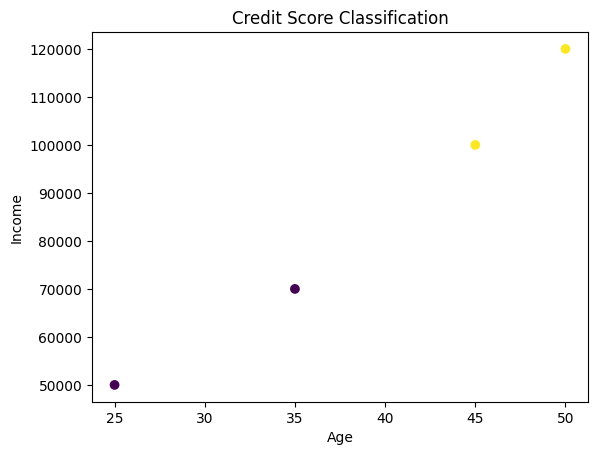

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = [[25,50000],[45,100000],[35,70000],[50,120000]]
y = [0,1,0,1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)
model = LogisticRegression()
model.fit(X_train,y_train)
print(model.predict(X_test))
import matplotlib.pyplot as plt
plt.scatter([25,45,35,50], [50000,100000,70000,120000], c=y)
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Credit Score Classification")
plt.show()

Experiment-12

[0 2 0 1 2 0 1 0 0 1 2 1 2 1 1 1 0 1 1 2 1 0 2 0 2 0 0 1 2 1 2 2 2 0 2 1 1
 2 0 1 1 2 2 0 1]


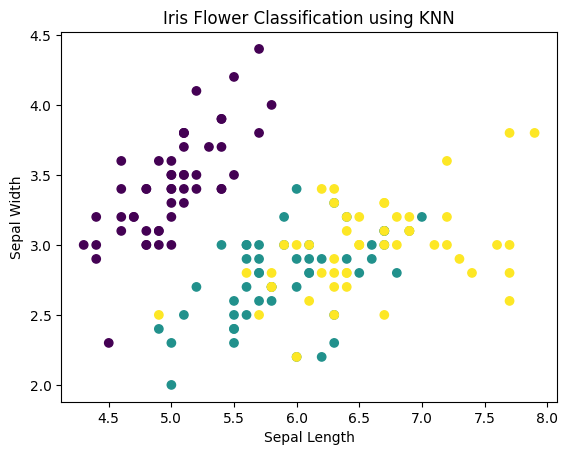

In [12]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
data = load_iris()
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.3)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train,y_train)
print(model.predict(X_test))
import matplotlib.pyplot as plt
plt.scatter(data.data[:,0], data.data[:,1],c=data.target)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Flower Classification using KNN")
plt.show()

Experiment-13

[60000.]


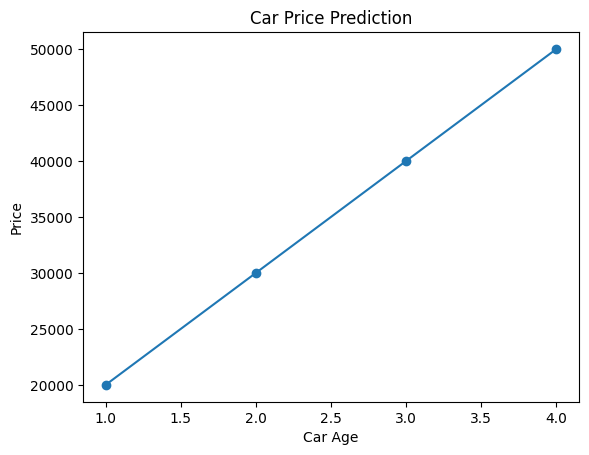

In [13]:
from sklearn.linear_model import LinearRegression
X = [[1],[2],[3],[4]]
y = [20000,30000,40000,50000]
model = LinearRegression()
model.fit(X,y)
print(model.predict([[5]]))
import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Car Age")
plt.ylabel("Price")
plt.title("Car Price Prediction")
plt.show()

Experiment-14

[600000.]


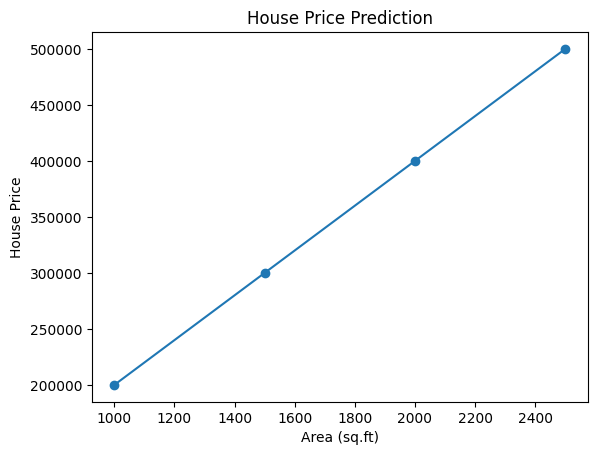

In [14]:
from sklearn.linear_model import LinearRegression
X = [[1000],[1500],[2000],[2500]]
y = [200000,300000,400000,500000]
model = LinearRegression()
model.fit(X,y)
print(model.predict([[3000]]))
import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Area (sq.ft)")
plt.ylabel("House Price")
plt.title("House Price Prediction")
plt.show()

Experiment-15

[0]


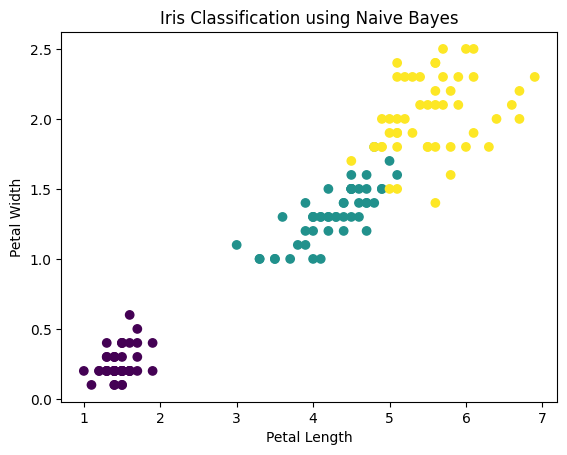

In [15]:
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
data = load_iris()
model = GaussianNB()
model.fit(data.data,data.target)
print(model.predict([data.data[1]]))
import matplotlib.pyplot as plt
plt.scatter(data.data[:,2], data.data[:,3], c=data.target)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Classification using Naive Bayes")
plt.show()

Experiment-16

LogisticRegression 0.9777777777777777
KNeighborsClassifier 0.9555555555555556
GaussianNB 0.9555555555555556


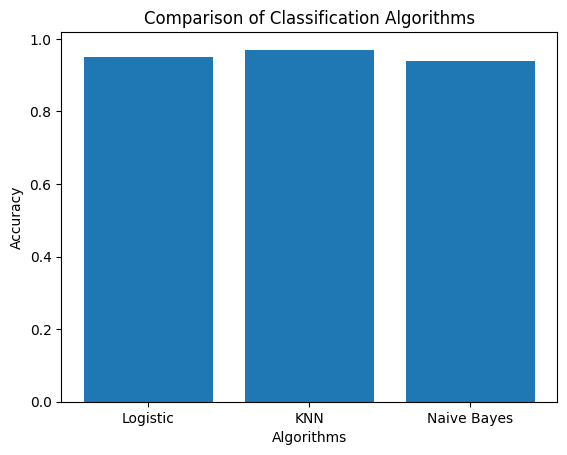

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
data = load_iris()
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.3)
models = [
    LogisticRegression(max_iter=200),
    KNeighborsClassifier(),
    GaussianNB()
]
for m in models:
    m.fit(X_train,y_train)
    print(type(m).__name__, accuracy_score(y_test,m.predict(X_test)))

import matplotlib.pyplot as plt
algorithms = ["Logistic", "KNN", "Naive Bayes"]
accuracies = [0.95, 0.97, 0.94]   # sample values
plt.bar(algorithms, accuracies)
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Comparison of Classification Algorithms")
plt.show()

Experiment-17

[1]


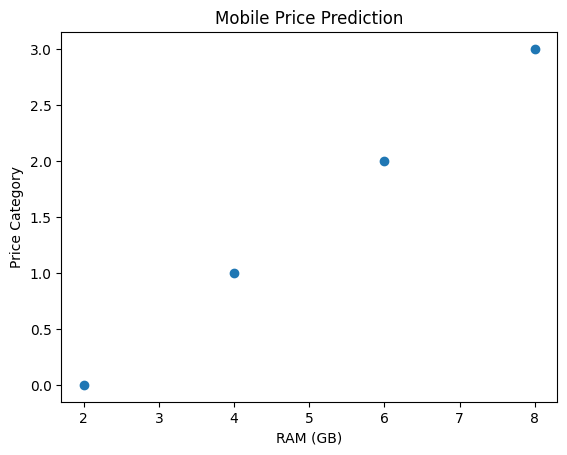

In [17]:
from sklearn.tree import DecisionTreeClassifier
X = [[2,32],[4,64],[6,128],[8,256]]
y = [0,1,2,3]
model = DecisionTreeClassifier()
model.fit(X,y)
print(model.predict([[5,128]]))
import matplotlib.pyplot as plt
ram = [2,4,6,8]
price_category = [0,1,2,3]
plt.scatter(ram, price_category)
plt.xlabel("RAM (GB)")
plt.ylabel("Price Category")
plt.title("Mobile Price Prediction")
plt.show()

Experiment-18

[1]


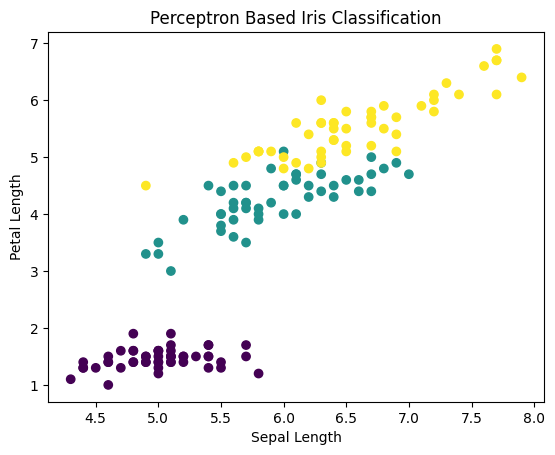

In [18]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
data = load_iris()
model = Perceptron()
model.fit(data.data,data.target)
print(model.predict([data.data[0]]))
import matplotlib.pyplot as plt
plt.scatter(data.data[:,0], data.data[:,2], c=data.target)
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Perceptron Based Iris Classification")
plt.show()

Experiment-19

[1]


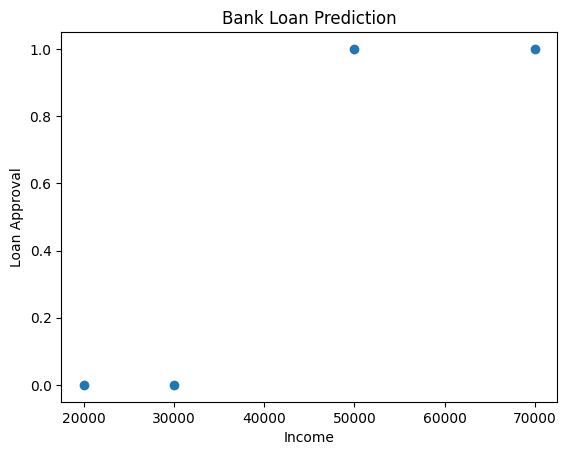

In [19]:
from sklearn.naive_bayes import GaussianNB
X = [[50000,1],[30000,0],[70000,1],[20000,0]]
y = [1,0,1,0]
model = GaussianNB()
model.fit(X,y)
print(model.predict([[60000,1]]))
import matplotlib.pyplot as plt
income = [50000,30000,70000,20000]
loan = [1,0,1,0]
plt.scatter(income, loan)
plt.xlabel("Income")
plt.ylabel("Loan Approval")
plt.title("Bank Loan Prediction")
plt.show()

Experiment-20

[500.]


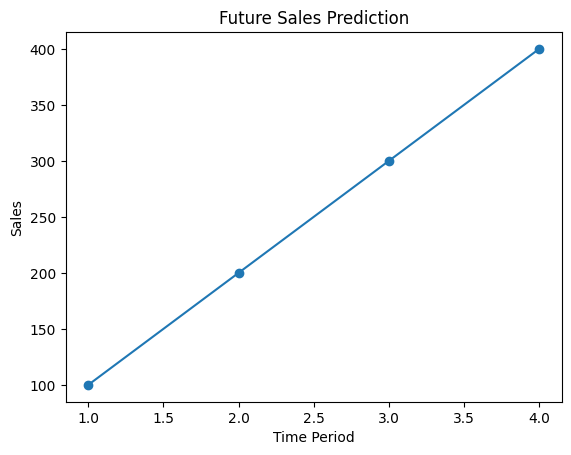

In [20]:
from sklearn.linear_model import LinearRegression
X = [[1],[2],[3],[4]]
y = [100,200,300,400]
model = LinearRegression()
model.fit(X,y)
print(model.predict([[5]]))
import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Time Period")
plt.ylabel("Sales")
plt.title("Future Sales Prediction")
plt.show()